## Usar apenas se estiver rodando no Google Colab:

In [1]:
! git clone https://github.com/EduardoShoiti/tech-challenge-3
%cd tech-challenge-3

Cloning into 'tech-challenge-3'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 40 (delta 5), reused 21 (delta 5), pack-reused 13 (from 1)
Receiving objects: 100% (40/40), 176.44 MiB | 27.81 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/tech-challenge-3


In [ ]:
# ! pip install -r requirements.txt

In [2]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 15.1 MB/s eta 0:00:00


In [3]:
! ls

data  Notebooks  README.md  requirements.txt


## Utils

In [4]:
%pip check

ipython 7.34.0 requires jedi, which is not installed.


In [1]:
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import optuna
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    recall_score,
    precision_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)

from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)


PROJECT_DIR = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_PATH = PROJECT_DIR / 'data' / 'sample' / 'data_sample_modeling.parquet'
assert DATA_PATH.exists(), f'Arquivo não encontrado: {DATA_PATH.resolve()}'



c:\Users\Shoiti\Desktop\Shoiti\PosTech - AI Scientist\tech-challenge-3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
RANDOM_STATE = 42
TARGET = 'alfabetizado'

# Métrica usada pelo Optuna para comparar configurações.
# ROC AUC é independente do threshold e mede a capacidade de ranking/separação.
OPTUNA_SCORING = "roc_auc"

# Quantidade de folds utilizada dentro APENAS do conjunto de treino.
N_SPLITS_CV = 5

N_TRIALS = {
    "lr": 30,
    "dt": 30,
    "rf": 10,
    "lgbm": 10,
    "nb": 30,
}

In [3]:
df = pd.read_parquet(DATA_PATH)
df.shape, df['ano'].value_counts().sort_index(), df[TARGET].value_counts(normalize=True)

((386816, 55),
 ano
 2023    174743
 2024    212073
 Name: count, dtype: int64,
 alfabetizado
 1    0.51305
 0    0.48695
 Name: proportion, dtype: float64)

## Higienização: constantes e leakage

A função abaixo remove automaticamente colunas constantes no conjunto de treino. As colunas de ID, o alvo, o ano e as variáveis explicitamente listadas como leakage também são removidas. A lista é conservadora: taxas e médias de alfabetização/proficiência do mesmo ano podem incluir informação posterior ou o próprio aluno.

In [4]:
# Identificadores não generalizam para novos alunos/escolas; `ano` apenas define o corte temporal.
ID_COLUMNS = ['id_aluno', 'id_municipio', 'codigo_uf', 'rede']
TIME_COLUMN = 'ano'

# Medidas da prova ou agregados calculados no período do rótulo: candidatas a leakage.
LEAKAGE_COLUMNS = [
    'proficiencia', 'peso_aluno', 'presenca', 'preenchimento_caderno', 'caderno',
    'municipio_taxa_alfabetizacao_pct', 'municipio_media_portugues',
    'uf_taxa_alfabetizacao_pct', 'uf_media_portugues',
    'brasil_taxa_alfabetizacao_pct',
]

def columns_to_remove(frame, target=TARGET):
    fixed = set([target, TIME_COLUMN, *ID_COLUMNS, *LEAKAGE_COLUMNS])
    # Metas futuras não são atributos individuais e podem introduzir sinal temporal artificial.
    fixed.update(c for c in frame.columns if c.startswith('meta_'))
    constants = {c for c in frame.columns if frame[c].nunique(dropna=False) <= 1}
    return sorted((fixed | constants) & set(frame.columns)), sorted(constants)

# O ajuste da lista de constantes ocorre apenas em 2023, evitando inspecionar o teste.
df_2023 = df.loc[df[TIME_COLUMN] == 2023].copy()
remove_columns, constant_columns = columns_to_remove(df_2023)
print('Constantes em 2023:', constant_columns)
print('Colunas removidas:', remove_columns)

Constantes em 2023: ['ano', 'brasil_taxa_alfabetizacao_pct', 'meta_brasil_2024_pct', 'meta_brasil_2025_pct', 'meta_brasil_2026_pct', 'meta_brasil_2027_pct', 'meta_brasil_2028_pct', 'meta_brasil_2029_pct', 'meta_brasil_2030_pct', 'meta_brasil_percentual_participacao_pct', 'meta_uf_2030_pct', 'sem_gestor', 'serie']
Colunas removidas: ['alfabetizado', 'ano', 'brasil_taxa_alfabetizacao_pct', 'caderno', 'codigo_uf', 'id_aluno', 'id_municipio', 'meta_brasil_2024_pct', 'meta_brasil_2025_pct', 'meta_brasil_2026_pct', 'meta_brasil_2027_pct', 'meta_brasil_2028_pct', 'meta_brasil_2029_pct', 'meta_brasil_2030_pct', 'meta_brasil_percentual_participacao_pct', 'meta_municipio_2024_pct', 'meta_municipio_2025_pct', 'meta_municipio_2026_pct', 'meta_municipio_2027_pct', 'meta_municipio_2028_pct', 'meta_municipio_2029_pct', 'meta_municipio_2030_pct', 'meta_municipio_nivel_alfabetizacao', 'meta_municipio_percentual_participacao_pct', 'meta_municipio_taxa_alfabetizacao_pct', 'meta_uf_2024_pct', 'meta_uf_202

## Separação temporal

A validação é uma amostra estratificada de 2023, usada para comparar e calibrar modelos. O teste é 2024 completo e só deve ser consultado no final.

In [6]:
train_2023, valid_2023 = train_test_split(
    df_2023, test_size=0.20, stratify=df_2023[TARGET], random_state=RANDOM_STATE
)
test_2024 = df.loc[df[TIME_COLUMN] == 2024].copy()

FEATURES = [c for c in df.columns if c not in remove_columns]
X_train, y_train = train_2023[FEATURES], train_2023[TARGET]
X_val, y_val = valid_2023[FEATURES], valid_2023[TARGET]
X_test, y_test = test_2024[FEATURES], test_2024[TARGET]

pd.DataFrame({
    'conjunto': ['treino (2023)', 'validação (2023)', 'teste (2024)'],
    'linhas': [len(X_train), len(X_val), len(X_test)],
    'taxa_alfabetizado': [y_train.mean(), y_val.mean(), y_test.mean()]
})

datasets_dev = {
    "Treino": (
        X_train,
        y_train
    ),
    "Validação": (
        X_val,
        y_val
    )
}

datasets_test = {
    "Teste": (
        X_test,
        y_test
    )
}

In [7]:
X_train

,id_escola,sigla_uf,regiao,rede_desc,pib,populacao,recusa,caracterizacao_orgao_gestor,escolaridade,escolaridade_formacao
299768,60009244,CE,Nordeste,Municipal,9891544000,355679.0,0,Secretaria exclusiva,Ensino superior completo,Outra
49684,60024070,RJ,Sudeste,Municipal,3956993000,20373.0,0,Secretaria em conjunto com outras políticas se...,Ensino superior completo,Biologia
201130,60036456,SC,Sul,Municipal,45511051000,616317.0,0,Secretaria exclusiva,Mestrado,Administração
181737,60019437,MG,Sudeste,Municipal,635552000,27635.0,0,Secretaria exclusiva,Mestrado,Pedagogia
96072,60039675,RS,Sul,Municipal,4647664000,224124.0,0,Secretaria exclusiva,Especialização,Pedagogia
...,...,...,...,...,...,...,...,...,...,...
364346,60002271,PA,Norte,Municipal,1297602000,67585.0,0,Secretaria exclusiva,Ensino médio (2º Grau) completo,NaN
284475,60007581,CE,Nordeste,Municipal,71512000,7262.0,0,Secretaria exclusiva,Especialização,Letras
133584,60006457,PI,Nordeste,Municipal,25943688000,866300.0,0,Secretaria exclusiva,Doutorado,Outra
154491,60024057,RJ,Sudeste,Municipal,11663534000,129612.0,0,Secretaria exclusiva,Especialização,Educação física


## Pipelines reutilizáveis de pré-processamento

In [8]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.frequency_maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            self.frequency_maps_[col] = (
                X[col]
                .value_counts(normalize=True, dropna=False)
                .to_dict()
            )

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            X[col] = (
                X[col]
                .map(self.frequency_maps_[col])
                .fillna(0)
            )

        return X

In [9]:
def create_preprocessor(
    onehot_cols=None,
    frequency_cols=None,
    standard_cols=None
):
    onehot_cols = onehot_cols or []
    frequency_cols = frequency_cols or []
    standard_cols = standard_cols or []

    transformers = []

    if onehot_cols:
        transformers.append(
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                onehot_cols
            )
        )

    if frequency_cols:
        transformers.append(
            (
                "frequency",
                FrequencyEncoder(),
                frequency_cols
            )
        )

    if standard_cols:
        transformers.append(
            (
                "standard",
                StandardScaler(),
                standard_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="passthrough",
        verbose_feature_names_out=False
    )

    return preprocessor

In [10]:
onehot_cols = [
    "regiao",
    "rede_desc"
]

frequency_cols = [
    "id_escola",
    "sigla_uf",
    "caracterizacao_orgao_gestor",
    "escolaridade",
    "escolaridade_formacao"
]

standard_cols = [
    "pib",
    "populacao"
]

In [11]:
preprocessor = create_preprocessor(
    onehot_cols=onehot_cols,
    frequency_cols=frequency_cols,
    standard_cols=standard_cols
)

## Função para avaliação do modelo

In [12]:
def evaluate_model(
    model,
    datasets,
    threshold="ks",
    threshold_dataset="Validação"
):
    """
    Avalia um modelo de classificação binária em um ou mais datasets.

    Pode ser utilizada tanto durante o desenvolvimento quanto
    na avaliação final do teste.

    Parameters
    ----------
    model : estimator ou sklearn Pipeline
        Modelo já treinado e com método predict_proba().

    datasets : dict
        Dicionário no formato:

        {
            "Treino": (X_train, y_train),
            "Validação": (X_val, y_val)
        }

        ou, para avaliação final:

        {
            "Teste": (X_test, y_test)
        }

    threshold : str ou float, default="ks"
        - "ks":
            encontra o threshold que maximiza o KS no
            dataset definido em `threshold_dataset`.

        - float:
            utiliza diretamente o threshold informado.

    threshold_dataset : str, default="Validação"
        Dataset utilizado para calcular o threshold KS.

        Normalmente deve ser "Validação".

        Não deve ser "Teste" no fluxo de desenvolvimento.

    Returns
    -------
    results_df : pandas.DataFrame
        Métricas calculadas para cada dataset.

    decision_threshold : float
        Threshold utilizado para gerar as classificações.
    """

    # =========================================================
    # 1. Validações iniciais
    # =========================================================

    if not isinstance(datasets, dict):
        raise TypeError(
            "`datasets` deve ser um dicionário."
        )

    if len(datasets) == 0:
        raise ValueError(
            "`datasets` não pode estar vazio."
        )

    # =========================================================
    # 2. Determinação do threshold
    # =========================================================

    if threshold == "ks":

        if threshold_dataset not in datasets:
            raise ValueError(
                f"O dataset '{threshold_dataset}' não existe em "
                f"`datasets`.\n\n"
                f"Datasets disponíveis: {list(datasets.keys())}\n\n"
                f"Para avaliação final de teste, utilize o "
                f"threshold já definido na validação."
            )

        X_threshold, y_threshold = datasets[
            threshold_dataset
        ]

        y_threshold_proba = model.predict_proba(
            X_threshold
        )[:, 1]

        fpr_threshold, tpr_threshold, thresholds = roc_curve(
            y_threshold,
            y_threshold_proba
        )

        # KS = TPR - FPR
        ks_values = (
            tpr_threshold
            - fpr_threshold
        )

        ks_idx = np.argmax(
            ks_values
        )

        decision_threshold = thresholds[
            ks_idx
        ]

        print(
            f"Threshold selecionado pelo KS "
            f"({threshold_dataset}): "
            f"{decision_threshold:.4f}"
        )

        print(
            f"KS máximo em {threshold_dataset}: "
            f"{ks_values[ks_idx]:.4f}"
        )

    else:

        decision_threshold = float(
            threshold
        )

        if not 0 <= decision_threshold <= 1:
            raise ValueError(
                "O threshold deve estar entre 0 e 1."
            )

        print(
            f"Threshold fixo utilizado: "
            f"{decision_threshold:.4f}"
        )

    # =========================================================
    # 3. Cálculo das métricas
    # =========================================================

    results = []
    predictions = {}

    for dataset_name, (X, y) in datasets.items():

        y_true = np.asarray(y)

        # Probabilidade da classe positiva
        y_proba = model.predict_proba(
            X
        )[:, 1]

        # Classe final
        y_pred = (
            y_proba >= decision_threshold
        ).astype(int)

        # -----------------------------------------------------
        # Métricas dependentes do threshold
        # -----------------------------------------------------

        recall = recall_score(
            y_true,
            y_pred
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        # -----------------------------------------------------
        # ROC / AUC
        # -----------------------------------------------------

        auc = roc_auc_score(
            y_true,
            y_proba
        )

        fpr, tpr, roc_thresholds = roc_curve(
            y_true,
            y_proba
        )

        # -----------------------------------------------------
        # KS
        # -----------------------------------------------------

        ks_values = (
            tpr - fpr
        )

        ks_idx = np.argmax(
            ks_values
        )

        ks = ks_values[
            ks_idx
        ]

        ks_threshold = roc_thresholds[
            ks_idx
        ]

        # -----------------------------------------------------
        # Precision-Recall
        # -----------------------------------------------------

        (
            precision_curve,
            recall_curve,
            pr_thresholds
        ) = precision_recall_curve(
            y_true,
            y_proba
        )

        avg_precision = average_precision_score(
            y_true,
            y_proba
        )

        # -----------------------------------------------------
        # Prevalência
        # -----------------------------------------------------

        prevalence = np.mean(
            y_true
        )

        # -----------------------------------------------------
        # Resultados
        # -----------------------------------------------------

        results.append({
            "Dataset": dataset_name,
            "Recall": recall,
            "Precision": precision,
            "Accuracy": accuracy,
            "AUC": auc,
            "KS": ks,
            "Average Precision": avg_precision,
            "Prevalência": prevalence
        })

        predictions[dataset_name] = {

            "y_true": y_true,
            "y_pred": y_pred,
            "y_proba": y_proba,

            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,

            "ks_values": ks_values,
            "ks_idx": ks_idx,
            "ks_threshold": ks_threshold,

            "precision_curve": precision_curve,
            "recall_curve": recall_curve,
            "pr_thresholds": pr_thresholds,

            "prevalence": prevalence
        }

    # =========================================================
    # 4. DataFrame de métricas
    # =========================================================

    results_df = (
        pd.DataFrame(results)
        .set_index("Dataset")
    )

    print("\nMétricas do modelo\n")

    try:

        display(
            results_df.style.format(
                "{:.4f}"
            )
        )

    except NameError:

        print(
            results_df.round(4)
        )

    # =========================================================
    # 5. Matrizes de confusão
    # =========================================================

    n_datasets = len(
        predictions
    )

    fig, axes = plt.subplots(
        1,
        n_datasets,
        figsize=(
            5 * n_datasets,
            4
        )
    )

    # Quando há apenas 1 dataset, axes não é array
    if n_datasets == 1:
        axes = [axes]

    for ax, (
        dataset_name,
        values
    ) in zip(
        axes,
        predictions.items()
    ):

        cm = confusion_matrix(
            values["y_true"],
            values["y_pred"],
            normalize="true"
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm
        )

        disp.plot(
            ax=ax,
            colorbar=False,
            values_format=".1%"
        )

        ax.set_title(
            f"Matriz de Confusão - "
            f"{dataset_name}"
        )

        ax.set_xlabel(
            "Classe predita"
        )

        ax.set_ylabel(
            "Classe real"
        )

    fig.suptitle(
        f"Matriz de Confusão "
        f"(Threshold = "
        f"{decision_threshold:.4f})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 6. Curvas KS
    # =========================================================

    fig, axes = plt.subplots(
        1,
        n_datasets,
        figsize=(
            6 * n_datasets,
            5
        ),
        sharex=True,
        sharey=True
    )

    if n_datasets == 1:
        axes = [axes]

    for ax, (
        dataset_name,
        values
    ) in zip(
        axes,
        predictions.items()
    ):

        # Ordena scores do maior para o menor
        order = np.argsort(
            values["y_proba"]
        )[::-1]

        y_sorted = (
            values["y_true"][order]
        )

        n_positive = np.sum(
            y_sorted == 1
        )

        n_negative = np.sum(
            y_sorted == 0
        )

        # Distribuições acumuladas
        cum_positive = (
            np.cumsum(
                y_sorted == 1
            )
            / n_positive
        )

        cum_negative = (
            np.cumsum(
                y_sorted == 0
            )
            / n_negative
        )

        population = (
            np.arange(
                1,
                len(y_sorted) + 1
            )
            / len(y_sorted)
        )

        ks_curve = (
            cum_positive
            - cum_negative
        )

        ks_position = np.argmax(
            ks_curve
        )

        ks_value = ks_curve[
            ks_position
        ]

        ax.plot(
            population,
            cum_positive,
            label="Positivos"
        )

        ax.plot(
            population,
            cum_negative,
            label="Negativos"
        )

        ax.vlines(
            x=population[
                ks_position
            ],
            ymin=cum_negative[
                ks_position
            ],
            ymax=cum_positive[
                ks_position
            ],
            linestyles="--",
            label=f"KS = {ks_value:.4f}"
        )

        ax.set_title(
            f"KS - {dataset_name}"
        )

        ax.set_xlabel(
            "Proporção acumulada "
            "da população"
        )

        ax.set_ylabel(
            "Distribuição acumulada"
        )

        ax.set_xlim(
            0,
            1
        )

        ax.set_ylim(
            0,
            1
        )

        ax.grid(
            alpha=0.3
        )

        ax.legend()

    fig.suptitle(
        "Curvas KS",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 7. Curvas ROC sobrepostas
    # =========================================================

    plt.figure(
        figsize=(8, 6)
    )

    for (
        dataset_name,
        values
    ) in predictions.items():

        auc = results_df.loc[
            dataset_name,
            "AUC"
        ]

        plt.plot(
            values["fpr"],
            values["tpr"],
            label=(
                f"{dataset_name} "
                f"(AUC = {auc:.4f})"
            )
        )

    # Baseline aleatório
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Aleatório (AUC = 0.50)"
    )

    plt.title(
        "Curva ROC"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate / Recall"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 8. Precision-Recall sobrepostas
    # =========================================================

    plt.figure(
        figsize=(8, 6)
    )

    for (
        dataset_name,
        values
    ) in predictions.items():

        avg_precision = results_df.loc[
            dataset_name,
            "Average Precision"
        ]

        plt.plot(
            values["recall_curve"],
            values["precision_curve"],
            label=(
                f"{dataset_name} "
                f"(AP = "
                f"{avg_precision:.4f})"
            )
        )

        # Baseline de cada conjunto
        plt.axhline(
            y=values["prevalence"],
            linestyle=":",
            alpha=0.5
        )

    plt.title(
        "Precision-Recall"
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 9. Retorno
    # =========================================================

    return (
        results_df,
        decision_threshold
    )

In [13]:
cv = StratifiedKFold(
    n_splits=N_SPLITS_CV,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def cv_score_model(model):
    """Retorna o ROC AUC médio do modelo nos folds do treino."""
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring=OPTUNA_SCORING,
        cv=cv,
        n_jobs=-1,
    )
    return float(scores.mean())


In [14]:
baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    ]),
    "LightGBM": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1)),
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("preprocessing", preprocessor),
        ("model", GaussianNB()),
    ]),
}

baseline_results = []

for name, model in baseline_models.items():
    score = cv_score_model(model)
    baseline_results.append({"Modelo": name, "CV ROC AUC baseline": score})

baseline_df = (
    pd.DataFrame(baseline_results)
    .sort_values("CV ROC AUC baseline", ascending=False)
    .reset_index(drop=True)
)

display(baseline_df.style.format({"CV ROC AUC baseline": "{:.4f}"}))


,Modelo,CV ROC AUC baseline
0,LightGBM,0.6554
1,Random Forest,0.6407
2,Decision Tree,0.6362
3,Logistic Regression,0.5487
4,Gaussian Naive Bayes,0.5454


## Tuning com Bayes Optimization (Optuna)

### Regressão Logística

In [16]:
def objective_lr(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "solver": "liblinear",
        "max_iter": 2000,
        "random_state": RANDOM_STATE,
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(**params)),
    ])

    return cv_score_model(model)


study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="logistic_regression",
)

study_lr.optimize(objective_lr, n_trials=N_TRIALS["lr"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_lr.best_value, 4))
print("Melhores parâmetros:")
display(study_lr.best_params)


Best trial: 22. Best value: 0.554447: 100%|██████████| 30/30 [01:57<00:00,  3.92s/it]

Melhor CV ROC AUC: 0.5544
Melhores parâmetros:


{'C': 0.00230824168034906, 'penalty': 'l1', 'class_weight': None}

### Decisiont Tree

In [17]:
def objective_dt(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "random_state": RANDOM_STATE,
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(**params)),
    ])

    return cv_score_model(model)


study_dt = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="decision_tree",
)

study_dt.optimize(objective_dt, n_trials=N_TRIALS["dt"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_dt.best_value, 4))
print("Melhores parâmetros:")
display(study_dt.best_params)


Best trial: 14. Best value: 0.647355: 100%|██████████| 30/30 [00:54<00:00,  1.82s/it]

Melhor CV ROC AUC: 0.6474
Melhores parâmetros:


{'criterion': 'gini',
 'max_depth': 15,
 'min_samples_split': 26,
 'min_samples_leaf': 22,
 'max_features': None,
 'class_weight': 'balanced'}

### Random Forest

In [18]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(**params)),
    ])

    return cv_score_model(model)


study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="random_forest",
)

study_rf.optimize(objective_rf, n_trials=N_TRIALS["rf"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_rf.best_value, 4))
print("Melhores parâmetros:")
display(study_rf.best_params)


Best trial: 0. Best value: 0.660301: 100%|██████████| 10/10 [28:09<00:00, 168.98s/it]

Melhor CV ROC AUC: 0.6603
Melhores parâmetros:


{'n_estimators': 500,
 'max_depth': 29,
 'min_samples_split': 15,
 'min_samples_leaf': 12,
 'max_features': 'sqrt',
 'bootstrap': True,
 'class_weight': None}

### LightGBM

In [19]:
def objective_lgbm(trial):
    max_depth = trial.suggest_int("max_depth", 3, 15)

    # Mantém num_leaves em uma faixa coerente com a profundidade escolhida.
    max_leaves = min(127, 2 ** max_depth)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1200, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 7, max_leaves),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "random_state": RANDOM_STATE,
        "verbosity": -1,
        "n_jobs": 1,
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", LGBMClassifier(**params)),
    ])

    return cv_score_model(model)


study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="lightgbm",
)

study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS["lgbm"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_lgbm.best_value, 4))
print("Melhores parâmetros:")
display(study_lgbm.best_params)


Best trial: 8. Best value: 0.661862: 100%|██████████| 10/10 [01:52<00:00, 11.21s/it]

Melhor CV ROC AUC: 0.6619
Melhores parâmetros:


{'max_depth': 14,
 'n_estimators': 600,
 'learning_rate': 0.014308552498147852,
 'num_leaves': 93,
 'min_child_samples': 79,
 'subsample': 0.8245108790277985,
 'colsample_bytree': 0.9083868719818244,
 'reg_alpha': 0.0002780739892288472,
 'reg_lambda': 0.0005065186776865479,
 'class_weight': None}

### Gaussian Naive Bayes

In [20]:
def objective_nb(trial):
    params = {
        "var_smoothing": trial.suggest_float(
            "var_smoothing",
            1e-12,
            1e-6,
            log=True,
        )
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", GaussianNB(**params)),
    ])

    return cv_score_model(model)


study_nb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="gaussian_nb",
)

study_nb.optimize(objective_nb, n_trials=N_TRIALS["nb"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_nb.best_value, 4))
print("Melhores parâmetros:")
display(study_nb.best_params)


Best trial: 6. Best value: 0.545815: 100%|██████████| 30/30 [00:35<00:00,  1.19s/it]

Melhor CV ROC AUC: 0.5458
Melhores parâmetros:


{'var_smoothing': 2.231010801867922e-12}

### Tuning vs Baseline

In [21]:
tuned_cv = {
    "Logistic Regression": study_lr.best_value,
    "Decision Tree": study_dt.best_value,
    "Random Forest": study_rf.best_value,
    "LightGBM": study_lgbm.best_value,
    "Gaussian Naive Bayes": study_nb.best_value,
}

comparison_cv = baseline_df.copy()
comparison_cv["CV ROC AUC tuned"] = comparison_cv["Modelo"].map(tuned_cv)
comparison_cv["ganho_tuning"] = (
    comparison_cv["CV ROC AUC tuned"] - comparison_cv["CV ROC AUC baseline"]
)
comparison_cv = comparison_cv.sort_values("CV ROC AUC tuned", ascending=False)

display(
    comparison_cv.style.format({
        "CV ROC AUC baseline": "{:.4f}",
        "CV ROC AUC tuned": "{:.4f}",
        "ganho_tuning": "{:+.4f}",
    })
)


,Modelo,CV ROC AUC baseline,CV ROC AUC tuned,ganho_tuning
0,LightGBM,0.6554,0.6619,+0.0064
1,Random Forest,0.6407,0.6603,+0.0196
2,Decision Tree,0.6362,0.6474,+0.0112
3,Logistic Regression,0.5487,0.5544,+0.0058
4,Gaussian Naive Bayes,0.5454,0.5458,+0.0004


In [26]:
best_lr = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        **study_lr.best_params,
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

best_dt = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        **study_dt.best_params,
        random_state=RANDOM_STATE,
    )),
])

best_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        **study_rf.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

best_lgbm = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LGBMClassifier(
        **study_lgbm.best_params,
        subsample_freq=1,
        random_state=RANDOM_STATE,
        verbosity=-1,
        n_jobs=-1,
    )),
])

best_nb = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB(**study_nb.best_params)),
])

best_models = {
    "Logistic Regression": best_lr,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "LightGBM": best_lgbm,
    "Gaussian Naive Bayes": best_nb,
}

for name, model in best_models.items():
    print(f"Treinando {name}...")
    model.fit(X_train, y_train)


Treinando Logistic Regression...


c:\Users\Shoiti\Desktop\Shoiti\PosTech - AI Scientist\tech-challenge-3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Treinando Decision Tree...
Treinando Random Forest...
Treinando LightGBM...
Treinando Gaussian Naive Bayes...


In [27]:
def validation_summary(model, X_val, y_val):
    y_proba = model.predict_proba(X_val)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_val, y_proba)
    ks_values = tpr - fpr
    ks_idx = int(np.argmax(ks_values))
    threshold_ks = float(thresholds[ks_idx])

    y_pred = (y_proba >= threshold_ks).astype(int)

    return {
        "AUC Validação": roc_auc_score(y_val, y_proba),
        "KS Validação": float(ks_values[ks_idx]),
        "AP Validação": average_precision_score(y_val, y_proba),
        "Threshold KS": threshold_ks,
        "Recall Validação": recall_score(y_val, y_pred),
        "Precision Validação": precision_score(y_val, y_pred, zero_division=0),
        "Accuracy Validação": accuracy_score(y_val, y_pred),
    }


validation_rows = []

for name, model in best_models.items():
    row = {"Modelo": name}
    row.update(validation_summary(model, X_val, y_val))
    row["CV ROC AUC"] = tuned_cv[name]
    validation_rows.append(row)

validation_comparison = (
    pd.DataFrame(validation_rows)
    .sort_values("AUC Validação", ascending=False)
    .reset_index(drop=True)
)

display(validation_comparison.style.format({
    col: "{:.4f}"
    for col in validation_comparison.columns
    if col != "Modelo"
}))


,Modelo,AUC Validação,KS Validação,AP Validação,Threshold KS,Recall Validação,Precision Validação,Accuracy Validação,CV ROC AUC
0,Random Forest,0.6646,0.2373,0.6688,0.5045,0.6093,0.6229,0.6186,0.6603
1,LightGBM,0.6637,0.2334,0.6693,0.5001,0.6128,0.6196,0.6167,0.6619
2,Decision Tree,0.6498,0.2114,0.6519,0.4851,0.6364,0.6016,0.6059,0.6474
3,Logistic Regression,0.5573,0.0914,0.5517,0.5008,0.6307,0.5412,0.5461,0.5544
4,Gaussian Naive Bayes,0.5511,0.0743,0.5405,0.5179,0.6363,0.5331,0.5376,0.5458


Modelo em inspeção: Random Forest
Threshold selecionado pelo KS (Validação): 0.5045
KS máximo em Validação: 0.2373

Métricas do modelo



,Recall,Precision,Accuracy,AUC,KS,Average Precision,Prevalência
Dataset,,,,,,,
Treino,0.6414,0.6646,0.6574,0.7225,0.3153,0.7280,0.5021
Validação,0.6093,0.6229,0.6186,0.6646,0.2373,0.6688,0.5021


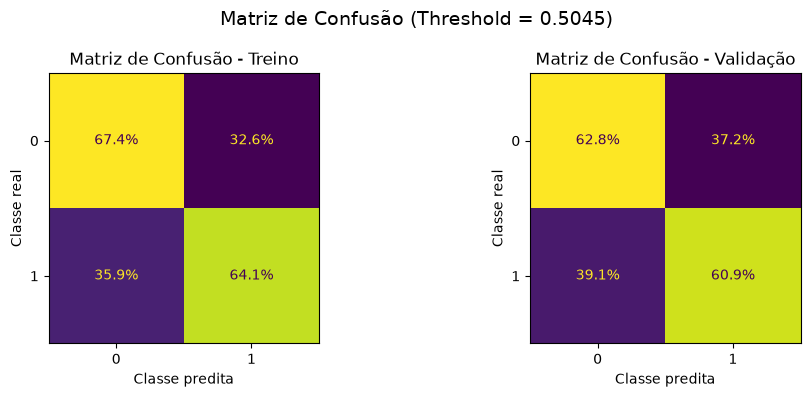

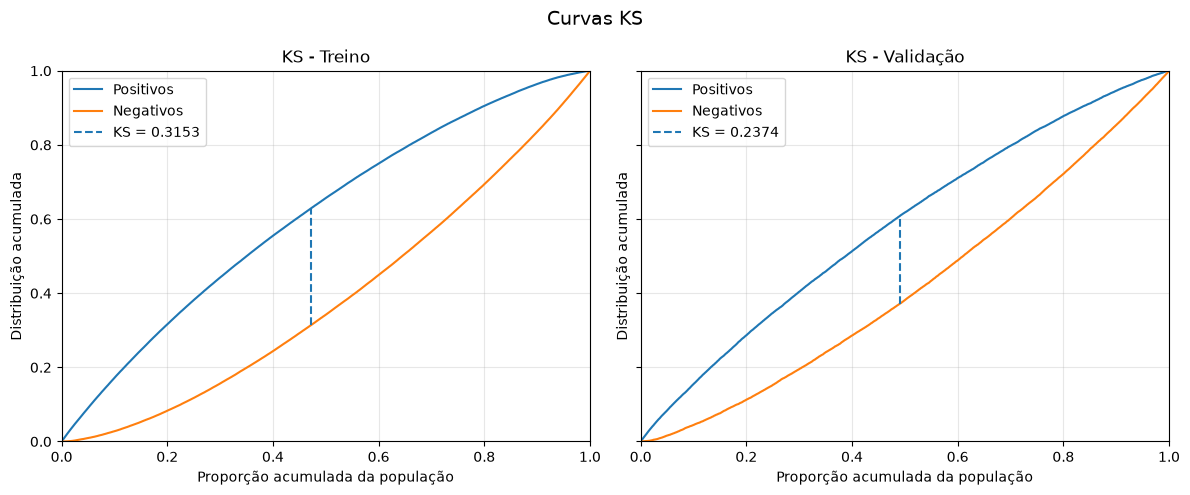

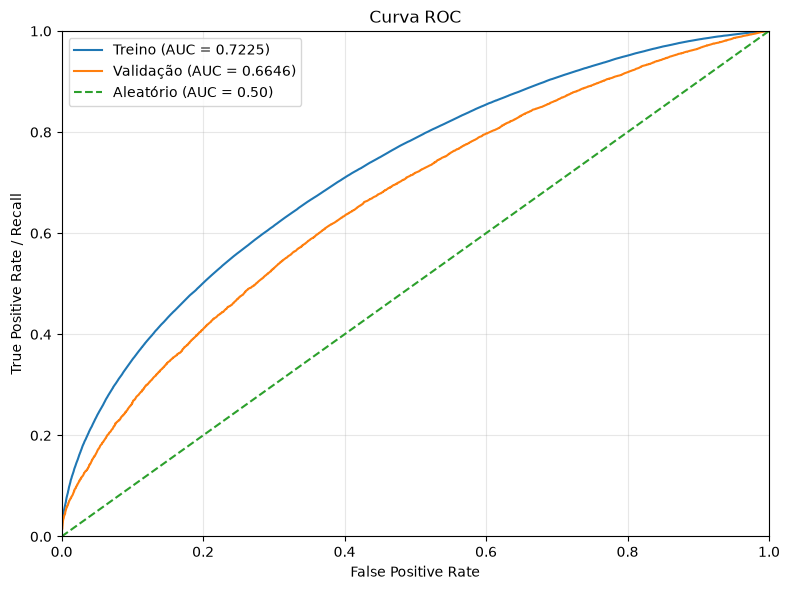

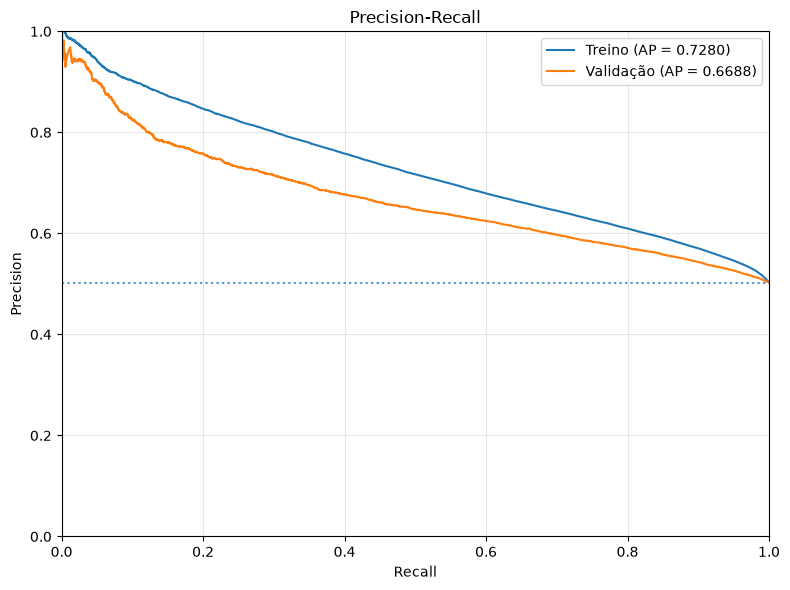

In [29]:
MODEL_TO_INSPECT = validation_comparison.iloc[0]["Modelo"]
model_to_inspect = best_models[MODEL_TO_INSPECT]

print("Modelo em inspeção:", MODEL_TO_INSPECT)

metrics_dev, threshold = evaluate_model(
    model=model_to_inspect,
    datasets=datasets_dev,
    threshold="ks",
    threshold_dataset="Validação"
)

## Escolha do modelo campeão e teste

Modelo em inspeção: Random Forest
Threshold fixo utilizado: 0.5045

Métricas do modelo



,Recall,Precision,Accuracy,AUC,KS,Average Precision,Prevalência
Dataset,,,,,,,
Teste,0.4767,0.6211,0.5750,0.6195,0.1672,0.6424,0.5221


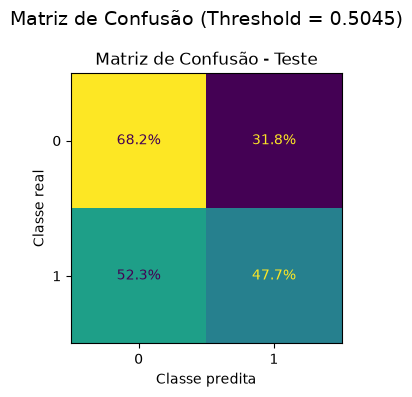

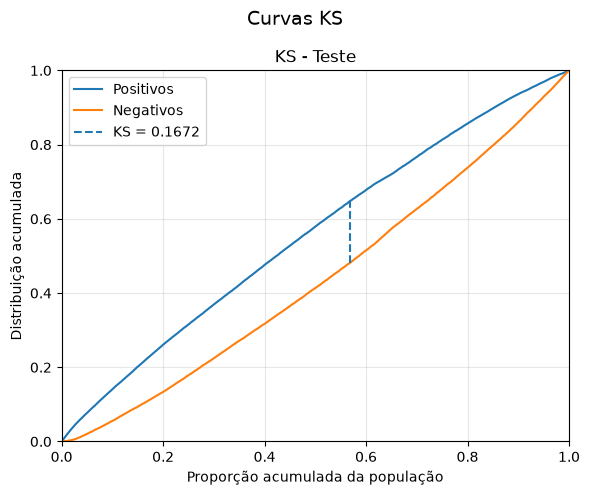

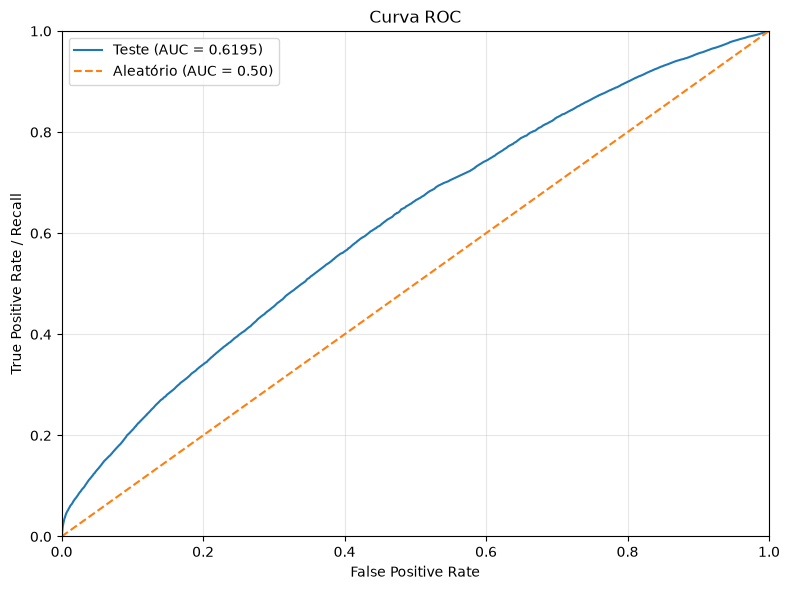

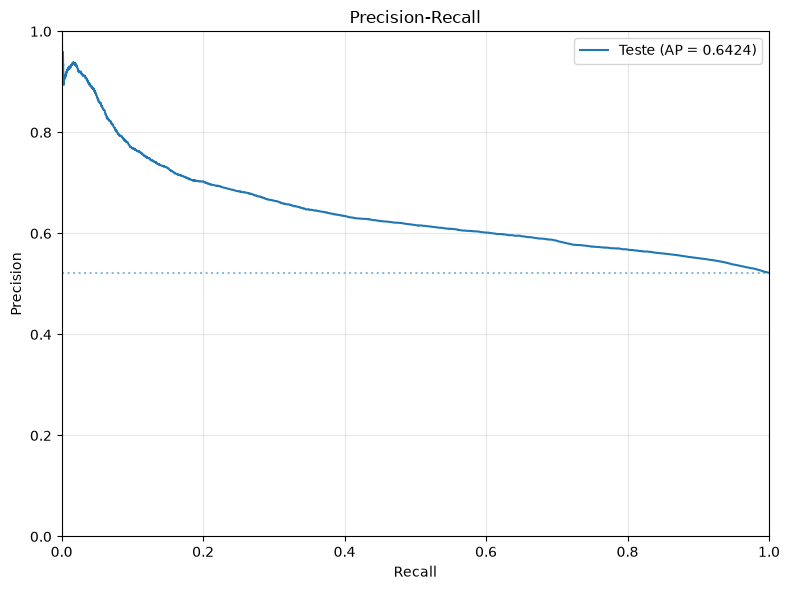

In [30]:
MODEL_TO_INSPECT = validation_comparison.iloc[0]["Modelo"]
model_to_inspect = best_models[MODEL_TO_INSPECT]

print("Modelo em inspeção:", MODEL_TO_INSPECT)

metrics_test, threshold = evaluate_model(
    model=model_to_inspect,
    datasets=datasets_test,
    threshold=threshold,
)